In [15]:
import Ocean_Opt_Algorithm as OOA
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import importlib

importlib.reload(OOA)

<module 'Ocean_Opt_Algorithm' from 'C:\\Users\\sebas\\PycharmProjects\\Advanced-Lab-Code\\Ocean_Optics_Specto\\Ocean_Opt_Algorithm.py'>

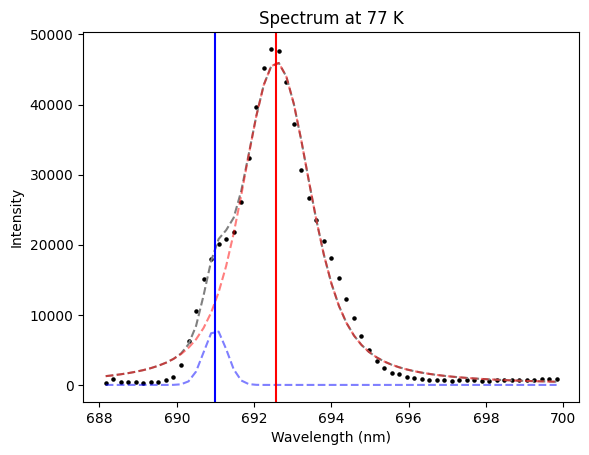

----- Results (77 K) -----
R1 Theory: 693.4
R1 Obs: 692.5770528592866 ± 0.09470124542493077
R1 frac: 0.9561655408347849
R2 Theory: 692.9
R2 Obs: 691.0000000000001 ± 0.07013954160149793
R2 frac: 0.043834459165215015
Reduced Chi Squared: 516.8066042981626


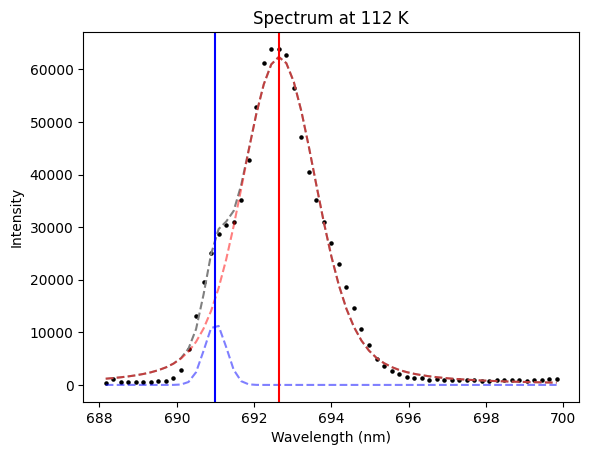

----- Results (112 K) -----
R1 Theory: 693.4
R1 Obs: 692.6482658118451 ± 0.06989988764691422
R1 frac: 0.9548270687973247
R2 Theory: 692.9
R2 Obs: 691.0000000000001 ± 0.05088527740726955
R2 frac: 0.04517293120267536
Reduced Chi Squared: 474.732005097061


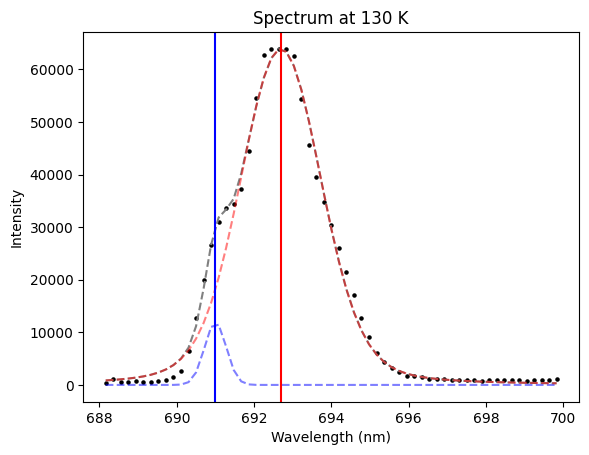

----- Results (130 K) -----
R1 Theory: 693.4
R1 Obs: 692.6930765917215 ± 0.05627788869324628
R1 frac: 0.9564411717221442
R2 Theory: 692.9
R2 Obs: 691.0000000000001 ± 0.04034619700306205
R2 frac: 0.04355882827785587
Reduced Chi Squared: 383.45889548880825


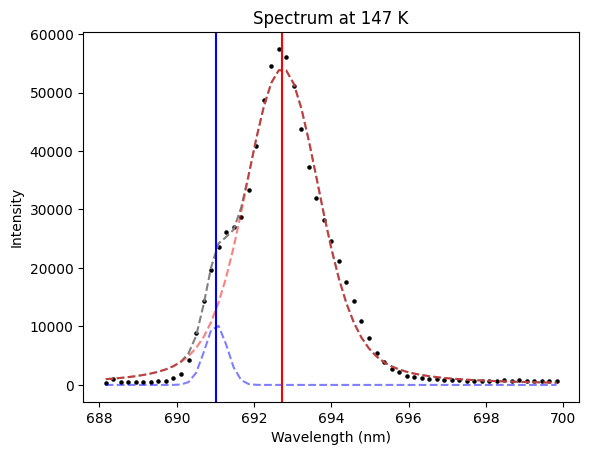

----- Results (147 K) -----
R1 Theory: 693.4
R1 Obs: 692.7312227942851 ± 0.06925591930435457
R1 frac: 0.9528139983670186
R2 Theory: 692.9
R2 Obs: 691.0176490786631 ± 0.05026943770663004
R2 frac: 0.04718600163298128
Reduced Chi Squared: 345.82782518309796


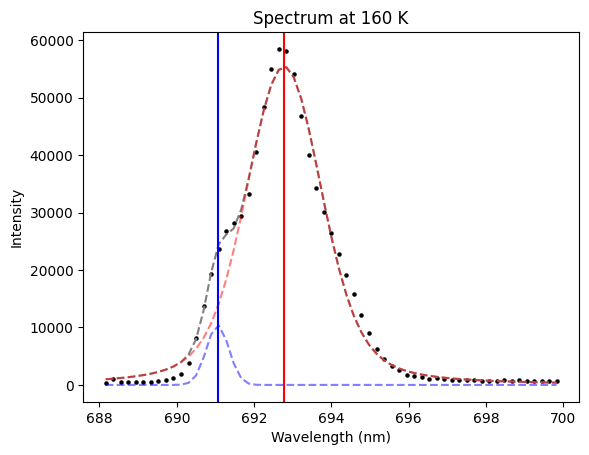

----- Results (160 K) -----
R1 Theory: 693.4
R1 Obs: 692.7749464154898 ± 0.06873988909397873
R1 frac: 0.9537452426171288
R2 Theory: 692.9
R2 Obs: 691.0580259517895 ± 0.04999707372661655
R2 frac: 0.04625475738287114
Reduced Chi Squared: 325.5842131839094


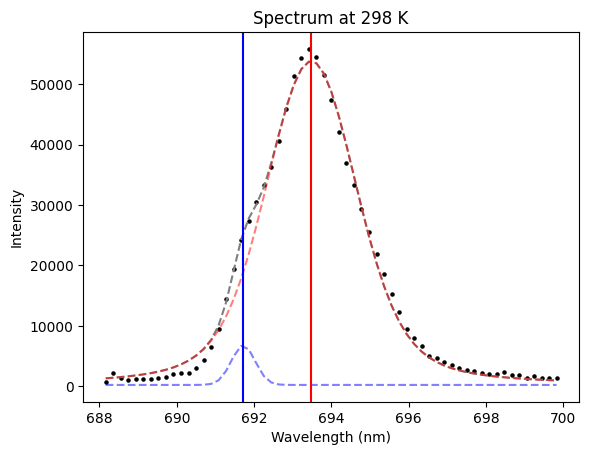

----- Results (298 K) -----
R1 Theory: 693.4
R1 Obs: 693.4803603266727 ± 0.0749828538820013
R1 frac: 0.9731812426014268
R2 Theory: 692.9
R2 Obs: 691.7198296882833 ± 0.05539007831232963
R2 frac: 0.026818757398573142
Reduced Chi Squared: 206.17781154453448


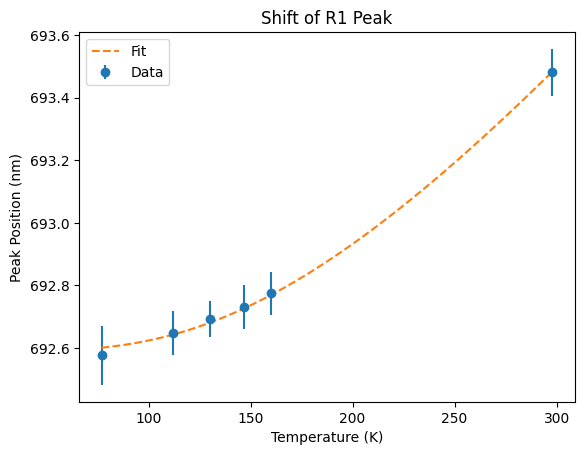

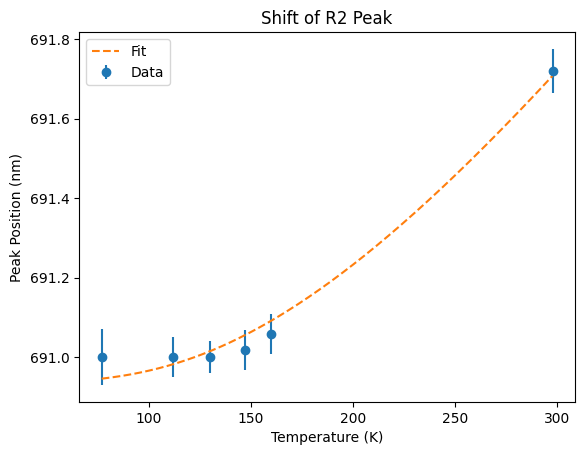

In [16]:
column_names = [
    ["W_77","I_77"],
    ["W_112","I_112"],
    ["W_130","I_130"],
    ["W_147","I_147"],
    ["W_160","I_160"],
    ["W_298","I_298"]
]

center1_guesses = {
    77: 691,
    112: 691,
    130: 691,
    147: 691,
    160: 691,
    298: 692
}

results = OOA.analyze_ruby_spectra(
    "Ocean_Opt_test.xlsx",
    column_names,
    center1_guesses=center1_guesses,
    Td_fixed_input=760
)

In [32]:
#Linewidth function
def voigt_FWHM(sigma, gamma):
    gamma_L = 2*sigma
    gamma_G = 2*np.sqrt(2*np.log(2))*gamma
    return 0.5346*gamma_L + np.sqrt(0.2166*gamma_L**2+gamma_G**2)

from scipy.integrate import quad
Td_fixed = 760
def debye_integrand(x):
    return x**3 / (np.exp(x) - 1)

def debye_integral(T, Td):

    if T <= 0:
        return 0  # avoid divide by zero

    upper = min(Td/T, 50)

    result, _ = quad(
        lambda x: x**3/(np.exp(x)-1),
        0,
        upper
    )

    return result

def ruby_shift_model(T, R0, alpha, Td):
    integral_vals = np.array([debye_integral(t, Td) for t in T])
    return R0 + alpha * (T / Td)**4 * integral_vals

def ruby_shift_model_fixed(T, R0, alpha):
    integral_vals = np.array([debye_integral(t, Td_fixed) for t in T])
    return R0 + alpha * (T / Td_fixed)**4 * integral_vals

In [48]:
temperatures = np.array([77, 112, 130, 147, 160, 298])

#Extract Data

R1_vals = []
R1_errs = []
R1_sigma = []
R1_sigma_errs = []
R1_gammas = []
R1_gamma_errs = []
R2_vals = []
R2_errs = []
R2_sigma = []
R2_sigma_errs = []
R2_gammas = []
R2_gamma_errs = []

for temp in temperatures:
    R1_vals.append(results[temp]["R1_obs"])
    R1_errs.append(results[temp]["R1_err"])
    R1_sigma.append(results[temp]["parameters"][3])
    R1_sigma_errs.append(np.sqrt(results[temp]["covariance"][3][3]))
    R1_gammas.append(results[temp]["parameters"][2])
    R1_gamma_errs.append(np.sqrt(results[temp]["covariance"][2][2]))
    R2_vals.append(results[temp]["R2_obs"])
    R2_errs.append(results[temp]["R2_err"])
    R2_sigma.append(results[temp]["parameters"][7])
    R2_sigma_errs.append(np.sqrt(results[temp]["covariance"][7][7]))
    R2_gammas.append(results[temp]["parameters"][6])
    R2_gamma_errs.append(np.sqrt(results[temp]["covariance"][6][6]))

R1_values = np.array(R1_vals)
R1_errs = np.array(R1_errs)
R1_sigma = np.array(R1_sigma)
R1_sigma_errs = np.array(R1_sigma_errs)
R1_gammas = np.array(R1_gammas)
R1_gamma_errs = np.array(R1_gamma_errs)
R2_values = np.array(R2_vals)
R2_errs = np.array(R2_errs)
R2_sigma = np.array(R2_sigma)
R2_sigma_errs = np.array(R2_sigma_errs)
R2_gammas = np.array(R2_gammas)
R2_gamma_errs = np.array(R2_gamma_errs)

#Calculate lineshift

R1_shift = R1_vals[-1] - R1_vals
R1_shift_err = np.sqrt((R1_errs[-1])**2+(R1_errs)**2)
R1_linewidth = voigt_FWHM(R1_sigma, R1_gammas)
R1_linewidth_err = np.sqrt((voigt_FWHM(R1_sigma+R1_sigma_errs, R1_gammas)-R1_linewidth)**2+(voigt_FWHM(R1_sigma, R1_gammas+R1_gamma_errs)-R1_linewidth)**2)

R2_shift = R2_vals[-1] - R2_vals
R2_shift_err = np.sqrt(((R2_vals[-1]+R2_errs[-1])-R2_vals)**2+(R2_vals[-1]-(R2_vals+R2_errs))**2)
R2_linewidth = voigt_FWHM(R2_sigma, R2_gammas)
R2_linewidth_err = np.sqrt((voigt_FWHM(R2_sigma+R2_sigma_errs, R2_gammas)-R2_linewidth)**2+(voigt_FWHM(R2_sigma, R2_gammas+R2_gamma_errs)-R2_linewidth)**2)

print(R1_vals)
print(R1_errs)
print(f"------------------")
print(R1_shift)
print(R1_shift_err)
print(f"------------------")
print(R1_vals[-1]+R1_errs[-1]-R1_vals)
print(R1_vals[-1]-R1_vals+R1_errs)

[np.float64(692.5770528592866), np.float64(692.6482658118451), np.float64(692.6930765917215), np.float64(692.7312227942851), np.float64(692.7749464154898), np.float64(693.4803603266727)]
[0.09470125 0.06989989 0.05627789 0.06925592 0.06873989 0.07498285]
------------------
[0.90330747 0.83209451 0.78728373 0.74913753 0.70541391 0.        ]
[0.12079219 0.1025106  0.09375302 0.10207258 0.10172316 0.10604177]
------------------
[0.97829032 0.90707737 0.86226659 0.82412039 0.78039677 0.07498285]
[0.99800871 0.9019944  0.84356162 0.81839345 0.7741538  0.07498285]


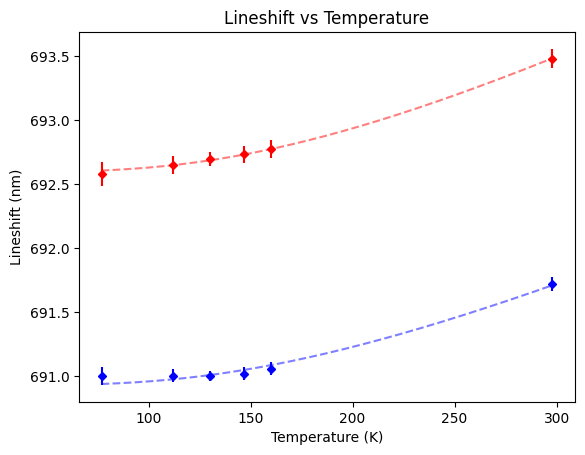

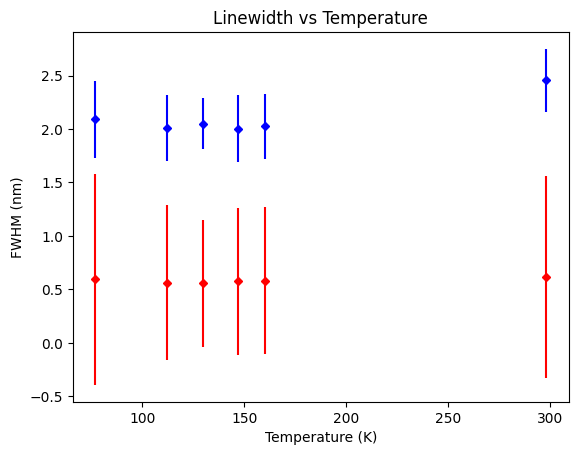

In [50]:
T_plot = np.arange(temperatures[0], temperatures[-1], 0.01)

p0_R1_shift = [R1_values[0], 1]

pop_R1_shift, cov_R1_shift = curve_fit(ruby_shift_model_fixed,
                           temperatures,
                           R1_values,
                           sigma=R1_errs,
                           absolute_sigma=True,
                           p0 = p0_R1_shift)

p0_R2_shift = [R2_values[0], 1]

pop_R2_shift, cov_R2_shift = curve_fit(ruby_shift_model_fixed,
                           temperatures,
                           R2_values,
                           sigma=R2_errs,
                           absolute_sigma=True,
                           p0 = p0_R2_shift)

plt.figure(1)
plt.errorbar(temperatures, R1_values, yerr=R1_errs, color = "red", markersize = 4, marker = "D", linestyle = "None")
plt.plot(T_plot, ruby_shift_model_fixed(T_plot, *pop_R1_shift), color = "red", linestyle = "--", alpha = 0.5)

plt.errorbar(temperatures, R2_values, yerr=R2_errs, color = "blue", markersize = 4, marker = "D", linestyle = "None")
plt.plot(T_plot, ruby_shift_model_fixed(T_plot, *pop_R2_shift), color = "blue", linestyle = "--", alpha = 0.5)

plt.xlabel("Temperature (K)")
plt.ylabel("Lineshift (nm)")
plt.title("Lineshift vs Temperature")
plt.show()

plt.figure(1)
plt.errorbar(temperatures, R1_linewidth, yerr= R1_linewidth_err, color = "red", markersize = 4, marker = "D", linestyle = "None")
plt.errorbar(temperatures, R2_linewidth, yerr= R2_linewidth_err, color = "blue", markersize = 4, marker = "D", linestyle = "None")

plt.xlabel("Temperature (K)")
plt.ylabel("FWHM (nm)")
plt.title("Linewidth vs Temperature")
plt.show()